In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# **Hough line built-in cv2**

(612, 394, 3)
(500, 400, 3)


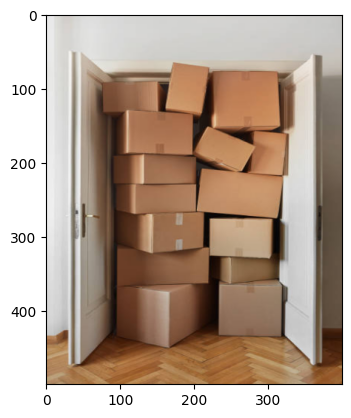

In [9]:
img = cv2.imread('boxess.jpg')
print(img.shape)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (400, 500))
print(img.shape)
plt.imshow(img)

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img1 = img.copy()
img2 = img.copy()

In [11]:
edges = cv2.Canny(gray, 200, 230, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=150) # edges, rho, theta, threshold
print(f'Number of lines: {len(lines)}')
print(lines) # lines is a list of lines, where each line is represented by its endpoints (x1, y1, x2, y2)

Number of lines: 5
[[[364 258 364  83]]

 [[ 46 472  46 151]]

 [[ 33 472  33 229]]

 [[ 39 425  39 305]]

 [[ 34 176  34  52]]]


In [13]:
for rho, theta in lines[0]:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(img1, (x1, y1), (x2, y2), (255, 0, 0), 2) # poin1, point2, color, thickness
plt.imshow(img1)

ValueError: too many values to unpack (expected 2)

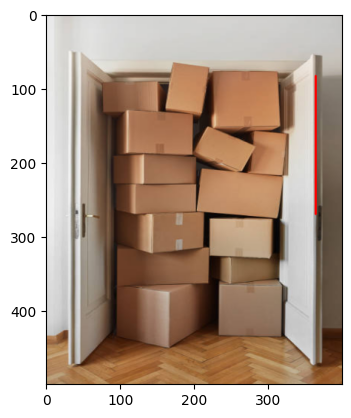

In [14]:
minLineLength = 50
maxLineGap = 5
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=150, minLineLength=minLineLength, maxLineGap=maxLineGap)
for x1, y1, x2, y2 in lines[0]:
    cv2.line(img2, (x1, y1), (x2, y2), (255, 0, 0), 2) # poin1, point2, color, thickness
plt.imshow(img2)

# **Hough Circles**

In [15]:
b_img = cv2.imread('balls.jpg')
b_img = cv2.cvtColor(b_img, cv2.COLOR_BGR2RGB)
b_gray = cv2.cvtColor(b_img, cv2.COLOR_RGB2GRAY)
b_gray = cv2.medianBlur(b_gray, 3) #image, kernel size, smoothing the image to reduce noise


In [16]:
circles = cv2.HoughCircles(b_gray, cv2.HOUGH_GRADIENT, dp=1, minDist=100, param1=50, param2=30, minRadius=0, maxRadius=0)
#gray image, gradient method, 
#dp: the inverse ratio of the accumulator resolution to the image resolution. For example, if dp=1, 
# the accumulator has the same resolution as the input image.
# If dp=2, the accumulator has half the resolution of the input image.
# minDist: Minimum distance between the centers of the detected circles. If the parameter is too small, 
# multiple circles may be falsely detected in the same location. If it is too large, some circles may be missed.
# param1: Higher threshold for the Canny edge detector (the lower one is twice smaller).
# param2: Accumulator threshold for the circle centers at the detection stage. The smaller it is, the more false circles may be detected. 
circles = np.uint16(np.around(circles))


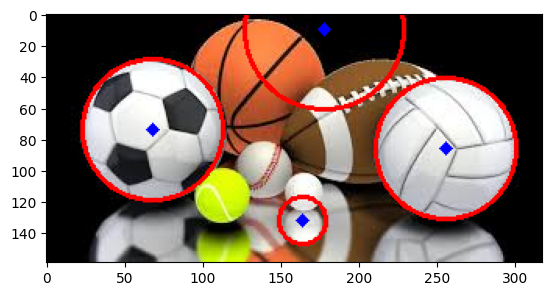

In [17]:
for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(b_img, (i[0], i[1]), i[2], (255, 0, 0), 2) # point, radius, color, thickness
    # draw the center of the circle
    cv2.circle(b_img, (i[0], i[1]), 2, (0, 0, 255), 3) # point, radius, color, thickness
plt.imshow(b_img)